## Introduction

We start our code by importing required packages 

- <code>pyscf</code>, <code>openfermion</code>: To load the hamiltonian geometry and get the fermionic and qubit Hamiltonian
- <code>cse</code>: For the Hamiltonian reduction 

In [1]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from typing import Iterator, Dict, Tuple, List, Callable, Optional, Sequence, Union

from pyscf import gto, scf, ao2mo, mcscf

import cirq
from openfermion import FermionOperator, jordan_wigner, get_sparse_operator
from scipy.sparse import csr_matrix
import scipy.linalg

from qiskit.quantum_info import SparsePauliOp
from qiskit_nature.second_q.operators import ElectronicIntegrals
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.mappers import JordanWignerMapper


In [25]:
%run "./LinLin_channel.ipynb"

wmax = 2.27456767
T_filter = 1.38118232
number of nonzero Fourier terms = 101

first few filter terms:
k=-99, c_k=-6.491268506973085e-05j
k=-97, c_k=-0.00013497258824897714j
k=-95, c_k=-0.0002103924345770992j
k=-93, c_k=-0.00029139557231845306j
k=-91, c_k=-0.00037821741492743315j
k=-89, c_k=-0.00047110710140819506j
k=-87, c_k=-0.0005703294094046108j
k=-85, c_k=-0.0006761669617415852j

first few gate parameters:
k=-99, c_k= 0-6.49127e-05j, theta_k=0.00001026, phi_k=-1.57079633
k=-97, c_k= 0-0.000134973j, theta_k=0.00002134, phi_k=-1.57079633
k=-95, c_k= 0-0.000210392j, theta_k=0.00003327, phi_k=-1.57079633
k=-93, c_k= 0-0.000291396j, theta_k=0.00004607, phi_k=-1.57079633
k=-91, c_k= 0-0.000378217j, theta_k=0.00005980, phi_k=-1.57079633
k=-89, c_k= 0-0.000471107j, theta_k=0.00007449, phi_k=-1.57079633
k=-87, c_k= 0-0.000570329j, theta_k=0.00009018, phi_k=-1.57079633
k=-85, c_k= 0-0.000676167j, theta_k=0.00010691, phi_k=-1.57079633
<class 'cirq.circuits.circuit.Circuit'>
273086000


## Molecular Hamiltonian

In [18]:
builder = HamiltonianBuilder()

mol = builder.build_molecule(
    geometry = [('H', (0.0, 0.0, 0.0)), ('H', (0.0, 0.0, 0.74))],
    basis="sto-3g",
    multiplicity=1,
    charge=0,
    active_indices=None,
    ancilla_index=0,
    n_active_electrons=None,
    n_active_orbitals=None,
    use_casscf_orbitals=True,
)

interaction_ham, fermion_ham, qubit_ham, H_mat, E_corr, n_system, ancilla, system_qubits = (
    mol.interaction, mol.fermion, mol.qubit, mol.matrix, mol.energy,
    mol.n_system, mol.ancilla, mol.system_qubits
)

In [19]:
E_corr, n_system, ancilla, system_qubits

(-1.1372838344885015,
 4,
 cirq.LineQubit(0),
 [cirq.LineQubit(1), cirq.LineQubit(2), cirq.LineQubit(3), cirq.LineQubit(4)])

### We keep the <code>E_nc_classical</code> by direct diagonalization of the non-contextual easy Hamiltonian, and keep working with the <code>H_c</code> for the quantum part, calculate the gs energy and add it to the <code>E_nc_classical</code> to get the total energy.

In [ ]:
from ham_reduce2  import reduce_hamiltonian


qubit_ham_red, fermion_ham_red, _ = reduce_hamiltonian(qubit_ham, fermion_ham)
qubit_ham_c_red, fermion_ham_c_red, E_nc_classical = reduce_hamiltonian(qubit_ham, fermion_ham)


Hc_red_mat = get_sparse_operator(qubit_ham_c_red).toarray()
E_corr = np.min(np.linalg.eigvalsh(Hc_red_mat))

E_total = E_nc_classical + E_corr

# Sparse matrix
H_sparse = get_sparse_operator(qubit_ham_c_red)
H_mat = H_sparse.toarray()

[reduce_hamiltonian] Original: 4 qubits, 15 Pauli terms
  H_nc: 15 terms   H_c: 0 terms   (H_nc contextual=False)
  Sector: 1 states kept (method='energy_window', eigenvalues [-1.13728383])
  H_eff dimension: 1×1
  Sector collapsed to scalar energy -1.137284
[reduce_hamiltonian] Original: 4 qubits, 15 Pauli terms
  H_nc: 15 terms   H_c: 0 terms   (H_nc contextual=False)
  Sector: 1 states kept (method='energy_window', eigenvalues [-1.13728383])
  H_eff dimension: 1×1
  Sector collapsed to scalar energy -1.137284


In [ ]:
E_total

-2.274567668977003

In [ ]:
from openfermion import QubitOperator
from openfermion.transforms import reverse_jordan_wigner

H_nc = (
    -2.0 * QubitOperator("Z0")
    -1.5 * QubitOperator("Z1")
    -0.8 * QubitOperator("Z0 Z1")
)

H_c = (
    0.40 * QubitOperator("X2 X3")
    + 0.30 * QubitOperator("Y2 Y3")
    + 0.20 * QubitOperator("Z0 X2")
    + 0.10 * QubitOperator("Z1 Z2")
    + 0.05 * QubitOperator("Z0 Z1 Z3")
    + 0.07 * QubitOperator("X0 X2")
    + 0.09 * QubitOperator("X1 Z3")
    + 0.06 * QubitOperator("Z0 Z1 X2 X3")
)

H_total = H_nc + H_c

H_total_ferm = reverse_jordan_wigner(H_total)

import importlib
import ham_reduce

importlib.reload(ham_reduce)

result = ham_reduce.reduce_hamiltonian(
    H_total,
    H_total_ferm,
    method="energy_window",
    Delta_E=0.1,
    verbose=True,
)

[reduce_hamiltonian] Original: 4 qubits, 11 Pauli terms
  H_nc: 7 terms   H_c: 4 terms   (H_nc contextual=False)
  Note: H_nc could not be converted to InteractionOperator.
  Reason: InteractionOperatorError('FermionOperator does not map to InteractionOperator.')
  Returning InteractionOperator = None for this block.
  Note: H_c could not be converted to InteractionOperator.
  Reason: InteractionOperatorError('FermionOperator does not map to InteractionOperator.')
  Returning InteractionOperator = None for this block.


KeyError: 'IIII'

In [ ]:
qubit_ham_red

-4.76 [] +
-0.3605551275463976 [Z0]

## Getting the coefficients

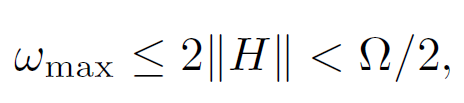

In [20]:
tau_k = 0.1

wmax = 2 * np.linalg.norm(H_mat, ord=2)


sq_filter = SquareWaveFilter()

filter_data = sq_filter.get_coefficients(
    L=wmax,
    K=100,
    tau=tau_k,
    A=1.0,
    window="lanczos",
    drop_zeros=True,
    sign=+1,
)

omega_filter = filter_data["omega_filter"]
cvals = filter_data["cvals"]
ks_filter = filter_data["ks_filter"]
filter_terms = filter_data["filter_terms"]

theta_filter = filter_data["theta_filter"]
phi_filter = filter_data["phi_filter"]
filter_gate_params = filter_data["filter_gate_params"]
T_filter = filter_data["T_filter"]

print(f"wmax = {wmax:.8f}")
print(f"T_filter = {T_filter:.8f}")
print(f"number of nonzero Fourier terms = {len(filter_terms)}")

print("\nfirst few filter terms:")
for k, ck in filter_terms[:8]:
    print(f"k={k:3d}, c_k={ck}")

print("\nfirst few gate parameters:")
for k, ck, theta_k, phi_k in filter_gate_params[:8]:
    print(
        f"k={k:3d}, c_k={ck: .6g}, "
        f"theta_k={theta_k:.8f}, phi_k={phi_k:.8f}"
    )

wmax = 2.27456767
T_filter = 1.38118232
number of nonzero Fourier terms = 101

first few filter terms:
k=-99, c_k=-6.491268506973085e-05j
k=-97, c_k=-0.00013497258824897714j
k=-95, c_k=-0.0002103924345770992j
k=-93, c_k=-0.00029139557231845306j
k=-91, c_k=-0.00037821741492743315j
k=-89, c_k=-0.00047110710140819506j
k=-87, c_k=-0.0005703294094046108j
k=-85, c_k=-0.0006761669617415852j

first few gate parameters:
k=-99, c_k= 0-6.49127e-05j, theta_k=0.00001026, phi_k=-1.57079633
k=-97, c_k= 0-0.000134973j, theta_k=0.00002134, phi_k=-1.57079633
k=-95, c_k= 0-0.000210392j, theta_k=0.00003327, phi_k=-1.57079633
k=-93, c_k= 0-0.000291396j, theta_k=0.00004607, phi_k=-1.57079633
k=-91, c_k= 0-0.000378217j, theta_k=0.00005980, phi_k=-1.57079633
k=-89, c_k= 0-0.000471107j, theta_k=0.00007449, phi_k=-1.57079633
k=-87, c_k= 0-0.000570329j, theta_k=0.00009018, phi_k=-1.57079633
k=-85, c_k= 0-0.000676167j, theta_k=0.00010691, phi_k=-1.57079633


### Getting the plot

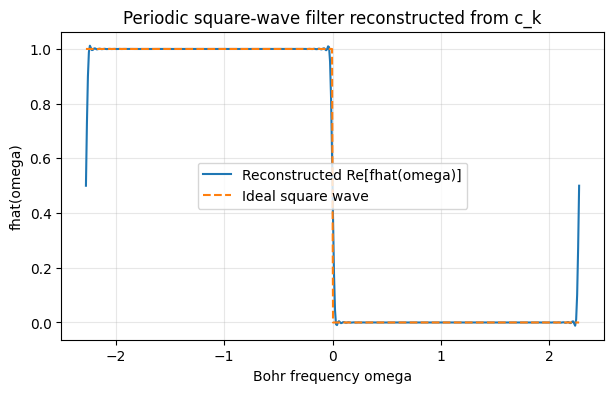

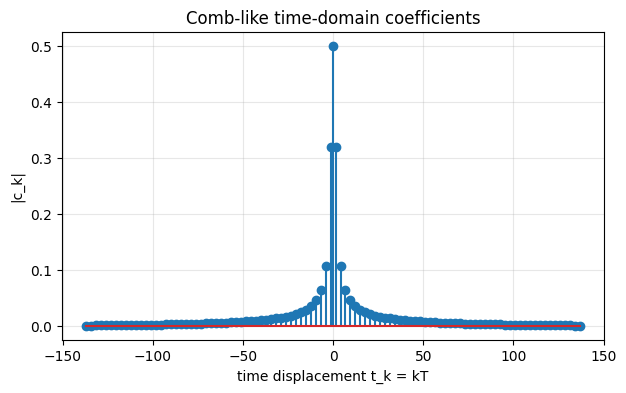

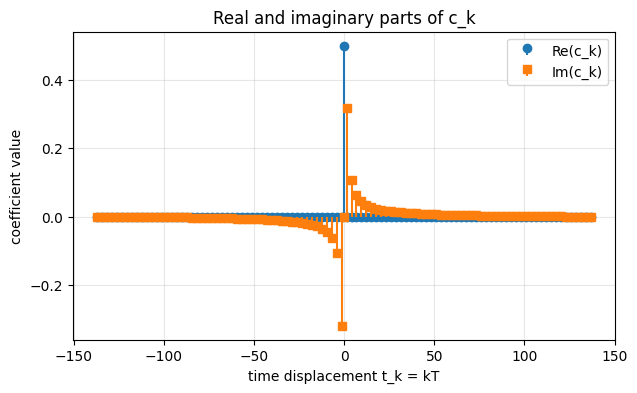

In [21]:
sq_filter.plot(filter_data, num_points=500)

In [22]:
H_sys_psum = fast_qubit_op_to_paulisum(qubit_ham, system_qubits)
H_sys_mat = pauli_sum_matrix(H_sys_psum, system_qubits)

In [14]:
k, ck = filter_terms[0]

circuit, qubits = A_ckt(
    k=k,
    ck=ck,
    tau_s=tau_k,
    jump_type="Ax",
)

print(circuit)

0: ───Rz(-0.5π)───H───@────────────────────────@───H───Rz(0.5π)───
                      │                        │
1: ───────────────────@───FSim(3.27e-06π, 0)───@──────────────────
                          │
2: ───────────────────────FSim(3.27e-06π, 0)──────────────────────


In [15]:
filter_terms[50]

(0, (0.5+0j))

In [23]:
pairs = [(0, 1, "Ax"), (0, 1, "Ay")]
weights = [0.5, 0.5]

W_circuit = build_W_circuit(
    ancilla=ancilla,
    system_qubits=system_qubits,
    H_int=interaction_ham,
    tau_s=tau_k,
    filter_terms=filter_terms,
    pairs=pairs,
    weights=weights,
    reps=None,
    trotter_steps_H=1,
    seed=123,
    T_filter=T_filter,
)

#print(W_circuit)

Chosen pair for this W block: (0, 1, 'Ay')


In [24]:
len(system_qubits)

4

In [ ]:
diag = WChainDiagnostics(
    system_qubits=system_qubits,
    H_int=interaction_ham,
    anc=ancilla,
    H_mat_sys=H_mat,
    n_system=n_system,
    filter_terms=filter_terms,
    T_filter=T_filter,
    tau=tau_k,
    E_corr=E_corr,
    occ_spin_orbs=[0, 1],
    N_applications=200,
    reps_per_W=1,
    trotter_steps_H=1,
    rng_seed=123,
    mol=mol if "mol" in globals() else None,
    geometry=geometry if "geometry" in globals() else None,
)

In [ ]:
#diag.circuit_vs_matrix_plot(rerun=False)

In [ ]:
#results = diag.three_way_comparison_report(rerun_circuit_matrix=False)

results = diag.three_way_comparison_report(rerun_circuit_matrix=False,exact=True,report=True)

In [ ]:
'''results_order = diag.parameter_sweep_subfigures(
    diff_occ=False,
    diff_order=True,
    diff_reps=False,
    trotter_orders=[1, 2],
)'''

In [ ]:
'''results_reps = diag.parameter_sweep_subfigures(
    diff_occ=False,
    diff_order=False,
    diff_reps=True,
    reps_per_W_list=[10],
    exact=False
)'''

In [ ]:
'''results_occ_reps = diag.parameter_sweep_subfigures(
    diff_occ=True,
    diff_order=False,
    diff_reps=False,
    occ_spin_orbs_list=[
        [2, 3, 4, 5],
        [0, 1],
        [0, 1, 2],
        [0, 1, 2, 3],
        [0, 1, 2, 3, 4],
        [1, 2, 3, 4],
    ],
    reps_per_W_list=5,
)'''

In [ ]:
drift_rows = one_step_eigenstate_energy_drifts(
    diag,
    basic=basic,
    W_cache=W_cache,
)

In [ ]:
# filter_leakage_info = filter_leakage_diagnostics(diag)


filter_leakage_info = filter_leakage_diagnostics(diag, print_summary=False, make_plots=False)
# filter_leakage_info = filter_leakage_diagnostics(diag, candidate_reps=[1, 3, 5, 9, 15, 25, 50])

Creating the subspace of sets $s$ which restricts the entire Hilbert space 
to the condition when $L$ = Total orbitals, $N_{\alpha}$ = Number of $\alpha$ electrons, $N_{\beta}$ = Number of $\beta$ electrons

In [ ]:
L = 4
N_alpha = 2
N_beta = 1

s = basis_alpha_beta(L, N_alpha, N_beta)
s

array([ 7, 13], dtype=uint32)

In [ ]:
# Decode the bitstrings
for bitstring in s:
    print(f"Bitstring: {bin(bitstring)[2:].zfill(L)}")

Bitstring: 0111
Bitstring: 1101


## Interpreting the Bitstrings

Here $L = 4$ spin-orbitals total: 2 α (even bits) and 2 β (odd bits).

| Bit index | 3 | 2 | 1 | 0 |
|-----------|---|---|---|---|
| Spin      | β | α | β | α |
| Orbital   | 1 | 1 | 0 | 0 |

---

### Bitstring: `0111`

| Bit index | 3 | 2 | 1 | 0 |
|-----------|---|---|---|---|
| Spin      | β | α | β | α |
| Orbital   | 1 | 1 | 0 | 0 |
| Occupied? | 0 | 1 | 1 | 1 |

Bits 0, 1, 2 are set → **α spin-orbital 0, β spin-orbital 0, α spin-orbital 1** are occupied.  
$N_\alpha = 2$ (spin-orbitals 0, 2) and $N_\beta = 1$ (spin-orbital 1). ✓

---

### Bitstring: `1101`

| Bit index | 3 | 2 | 1 | 0 |
|-----------|---|---|---|---|
| Spin      | β | α | β | α |
| Orbital   | 1 | 1 | 0 | 0 |
| Occupied? | 1 | 1 | 0 | 1 |

Bits 0, 2, 3 are set → **α spin-orbital 0, α spin-orbital 1, β spin-orbital 1** are occupied.  
$N_\alpha = 2$ (spin-orbitals 0, 2) and $N_\beta = 1$ (spin-orbital 3). ✓

---

### Summary

$L = 4$ spin-orbitals, giving 2 α slots (bits 0, 2) and 2 β slots (bits 1, 3).  
Both determinants have $N_\alpha = 2,\ N_\beta = 1$, but the $\beta$ electron
occupies a different spin-orbital:

| Bitstring | α occupied (bits) | β occupied (bit) |
|-----------|-------------------|------------------|
| `0111`    | 0, 2              | 1 (β spin-orbital 0) |
| `1101`    | 0, 2              | 3 (β spin-orbital 1) |

These are the only two valid Slater determinants for $L = 4,\ N_\alpha = 2,\ N_\beta = 1$,
since there is only $\binom{2}{2} = 1$ way to fill the α slots
and $\binom{2}{1} = 2$ ways to place the single β electron.

# Define the subspace where $N_{\alpha}=N_{\beta}$ for a given $L$

In [ ]:
L = 4

s_closed = []
for N in range(L // 2 + 1):          # N = 0, 1, 2  (can't exceed available α or β slots)
    dets = basis_alpha_beta(L, N, N)
    s_closed.append(dets)
    print(f"N_α = N_β = {N}  →  {len(dets)} determinants")

s_closed = np.concatenate(s_closed)
#print(f"\nTotal determinants in closed-shell subspace: {len(s_closed)}")
s_closed

N_α = N_β = 0  →  1 determinants
N_α = N_β = 1  →  4 determinants
N_α = N_β = 2  →  1 determinants


array([ 0,  3,  6,  9, 12, 15], dtype=uint32)

## Hydrogen exchange

In [42]:
import numpy as np
import sys
import typing
import cirq
# ---> 1. Trick python into thinking the legacy cirq modules exist
class DummyCirqWorkarounds:
    NotImplementedType = type(NotImplemented)
sys.modules['cirq.type_workarounds'] = DummyCirqWorkarounds()
# Patch the removed OpTree type alias used by Qualtran/pyLIQTR
if not hasattr(cirq.ops.op_tree, 'OpTree'):
    cirq.ops.op_tree.OpTree = getattr(cirq, 'OP_TREE', typing.Any)




from pyLIQTR.utils.printing                 import openqasm
from openfermion.chem                       import  MolecularData
from openfermionpyscf                       import  run_pyscf

from pyLIQTR.ProblemInstances.getInstance   import  getInstance
from pyLIQTR.BlockEncodings.getEncoding     import  getEncoding, VALID_ENCODINGS

from pyLIQTR.qubitization.qsvt_dynamics import qsvt_dynamics, simulation_phases
from pyLIQTR.utils.circuit_decomposition    import  circuit_decompose_multi

def struc2ham(structure):
    mol_data = MolecularData(structure,'sto3g',1,0)
    mol = run_pyscf(mol_data, run_scf=1, run_mp2=0, run_cisd=0, run_ccsd=0, run_fci=1, verbose=1)
    mol_ham         =   mol.get_molecular_hamiltonian()
    return mol_ham

def QSVT(mol_ham):
    model    =   getInstance("ChemicalHamiltonian",mol_ham=mol_ham)
    scaled_times = model.alpha
    eps = 0.001

    encoding=getEncoding(VALID_ENCODINGS.PauliLCU)

    phases = simulation_phases(times=scaled_times, eps=eps, precompute=False, phase_algorithm="random")
    gate_qsvt = qsvt_dynamics(encoding=encoding, instance=model, phase_sets=phases)

    print(circuit_decompose_multi(gate_qsvt.circuit, 1))

def make_multiscale_displacements(
    fine_dx=0.005,
    fine_steps=4,
    coarse_dx=0.02,
    coarse_steps=4,
    include_zero=False,
):
    """
    Make a 1D displacement stencil with dense points near 0
    and coarser points farther away.

    Example:
        fine_dx=0.005, fine_steps=4 gives:
            ±0.005, ±0.010, ±0.015, ±0.020

        coarse_dx=0.02, coarse_steps=4 gives:
            ±0.040, ±0.060, ±0.080, ±0.100

    The fine and coarse regions are merged without duplicates.
    """

    offsets = []

    if include_zero:
        offsets.append(0.0)

    # Fine region near the reference geometry
    for n in range(1, fine_steps + 1):
        offsets.append(+n * fine_dx)
        offsets.append(-n * fine_dx)

    # Coarse region farther away
    fine_radius = fine_steps * fine_dx

    for n in range(1, coarse_steps + 1):
        d = fine_radius + n * coarse_dx
        offsets.append(+d)
        offsets.append(-d)

    # Remove duplicates and sort
    offsets = sorted(set(np.round(offsets, 12)))

    return offsets

def displace_multiscale(
    coords,
    fine_dx=0.005,
    fine_steps=4,
    coarse_dx=0.02,
    coarse_steps=4,
    include_original=True,
):
    """
    Generate displaced geometries using a multiscale finite-difference stencil.

    More Hamiltonians are generated near the original geometry.
    Fewer Hamiltonians are generated farther away.

    Returns:
        new_coord, metadata

    metadata contains:
        atom_index
        cartesian_direction
        displacement
        region: "fine", "coarse", or "original"
    """

    coords = np.asarray(coords, dtype=float)

    if include_original:
        yield np.copy(coords), {
            "atom_index": None,
            "cartesian_direction": None,
            "displacement": 0.0,
            "region": "original",
        }

    offsets = make_multiscale_displacements(
        fine_dx=fine_dx,
        fine_steps=fine_steps,
        coarse_dx=coarse_dx,
        coarse_steps=coarse_steps,
        include_zero=False,
    )

    fine_radius = fine_steps * fine_dx

    for i in range(len(coords)):
        for j in range(3):
            for d in offsets:
                new_coord = np.copy(coords)
                new_coord[i, j] += d

                region = "fine" if abs(d) <= fine_radius + 1e-12 else "coarse"

                yield new_coord, {
                    "atom_index": i,
                    "cartesian_direction": j,
                    "displacement": d,
                    "region": region,}
                

d = 0.74
atoms = ["H", "H"]
coords = np.array([
    [0.0, 0.0,  d / 2],
    [0.0, 0.0, -d / 2],
])

displaced_geometries = displace_multiscale(
    coords,
    fine_dx=0.0025,      # dense near original geometry
    fine_steps=4,        # ±0.0025, ±0.005, ±0.0075, ±0.010
    coarse_dx=0.2,      # coarse farther away
    coarse_steps=4,      # then ±0.030, ±0.050, ±0.070, ±0.090
    include_original=True,
)
geometries = []
for newc, info in displaced_geometries:
    structure = list(zip(atoms, newc))
    #print(info)
    print(structure)
    geometries.append(structure)

    # mol_ham = struc2ham(structure)
    # QSVT(mol_ham)

[('H', array([0.  , 0.  , 0.37])), ('H', array([ 0.  ,  0.  , -0.37]))]
[('H', array([-0.81,  0.  ,  0.37])), ('H', array([ 0.  ,  0.  , -0.37]))]
[('H', array([-0.61,  0.  ,  0.37])), ('H', array([ 0.  ,  0.  , -0.37]))]
[('H', array([-0.41,  0.  ,  0.37])), ('H', array([ 0.  ,  0.  , -0.37]))]
[('H', array([-0.21,  0.  ,  0.37])), ('H', array([ 0.  ,  0.  , -0.37]))]
[('H', array([-0.01,  0.  ,  0.37])), ('H', array([ 0.  ,  0.  , -0.37]))]
[('H', array([-0.0075,  0.    ,  0.37  ])), ('H', array([ 0.  ,  0.  , -0.37]))]
[('H', array([-0.005,  0.   ,  0.37 ])), ('H', array([ 0.  ,  0.  , -0.37]))]
[('H', array([-0.0025,  0.    ,  0.37  ])), ('H', array([ 0.  ,  0.  , -0.37]))]
[('H', array([0.0025, 0.    , 0.37  ])), ('H', array([ 0.  ,  0.  , -0.37]))]
[('H', array([0.005, 0.   , 0.37 ])), ('H', array([ 0.  ,  0.  , -0.37]))]
[('H', array([0.0075, 0.    , 0.37  ])), ('H', array([ 0.  ,  0.  , -0.37]))]
[('H', array([0.01, 0.  , 0.37])), ('H', array([ 0.  ,  0.  , -0.37]))]
[('H', arr

In [29]:
from pyLIQTR.utils.resource_analysis import estimate_resources

For all geometries in geometries, make the W_chain channel for a fixed number of N_applications (modify that according to the geoemtry displacement) until it saturates and plot the overlap between these two consecutive channels (not consecutive W, that's the lower level structure)

In [ ]:
geometries = np.array(geometries)

for struct in geometries:
    diag = WChainDiagnostics(
        system_qubits=system_qubits,
        H_int=interaction_ham,
        anc=ancilla,
        H_mat_sys=H_mat,
        n_system=n_system,
        filter_terms=filter_terms,
        T_filter=T_filter,
        tau=tau_k,
        E_corr=E_corr,
        occ_spin_orbs=[0, 1],
        N_applications=200,
        reps_per_W=1,
        trotter_steps_H=1,
        mol=mol if "mol" in globals() else None,
        geometry=struct,
    )

In [45]:
from openfermion.circuits import trotter

trotter_target = 5.2e-2

# Lists to store the data for plotting
s_coords = []
t_counts = []

print(f"Scanning over {len(geometries)} geometries to find T-count for target precision {trotter_target}...")

for name, atom_str in geometries.items():
    print(f"\n==============================")
    print(f"Processing geometry: {name}")

    # Extract the reaction coordinate 's' dynamically from the dictionary key (e.g. 'H3_s_-0.150')
    try:
        s_val = float(name.split("_s_")[-1])
    except ValueError:
        s_val = len(s_coords) # Fallback if standard naming wasn't used

    # 1. Dynamically build PySCF geometry
    geo_list = []
    for atom in atom_str.split(';'):
        parts = atom.split()
        geo_list.append((parts[0], (float(parts[1]), float(parts[2]), float(parts[3]))))

    basis = 'sto-3g'
    multiplicity = 2  
    charge = 0

    molecule = MolecularData(geo_list, basis, multiplicity, charge)
    molecule = run_pyscf(molecule, run_scf=True, run_fci=True, verbose=0)
    
    # Using your active space parameters
    if "LiH" in name:
        occupied_indices = [0]
        active_indices = [1, 2, 3, 4]
    else:
        occupied_indices = []
        active_indices = [0, 1]

    fermion_ham = molecule.get_molecular_hamiltonian(
        occupied_indices=occupied_indices, 
        active_indices=active_indices
    )
    qubit_ham = jordan_wigner(fermion_ham)
    
    H_sparse = get_sparse_operator(qubit_ham)
    H_mat = H_sparse.toarray()

    n_system = int(np.log2(H_mat.shape[0]))
    ancilla = cirq.LineQubit(0)
    system_qubits = [cirq.LineQubit(i) for i in range(1, n_system + 1)]

    tau_s = 5
    
    # 2. Iteratively search for the step count that achieves the target epsilon
    U_exact = scipy.linalg.expm(-1j * tau_s * H_mat)
    
    best_steps = 1
    best_t_count = 0
    custom_algorithm = trotter.LowRankTrotterAlgorithm(final_rank=2)

    while True:
        full_ops = trotter.simulate_trotter(
                system_qubits, fermion_ham,
                time=tau_s,       
                n_steps=best_steps,
                omit_final_swaps=True,
                algorithm=custom_algorithm)
        
        U_circ = cirq.Circuit(full_ops, strategy=cirq.InsertStrategy.EARLIEST)
        U_trot = cirq.unitary(U_circ)
        
        # Calculate Phase-aligned Frobenius error
        ip = np.vdot(U_exact.ravel(), U_trot.ravel())
        phase = ip / abs(ip) if abs(ip) > 0 else 1.0
        diff = np.linalg.norm(U_trot - phase * U_exact)
        #print(f"    Trying steps={best_steps} | error={diff:.6e} | target={trotter_target}")
        
        # If we reached the target precision, extract the T-count and STOP the local search
        if diff <= trotter_target:
            res = estimate_resources(U_circ, profile=False)
            best_t_count = res.get('T', 0)
            print(f"  → Found! Steps={best_steps} | error={diff:.3e} | T-Count={best_t_count}")
            break
            
        best_steps += 2 # Increment by 2 to scan faster 
        
        if best_steps > 300:
            print(f"  → Warning: Max 300 steps reached without hitting target (error={diff:.3e})")
            res = estimate_resources(U_circ, profile=False)
            best_t_count = res.get('T', 0)
            break
            
    # Record the final coordinates and T-count 
    s_coords.append(s_val)
    t_counts.append(best_t_count)

# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

# Sort by s-coordinate just in case dictionary keys were unordered
order = np.argsort(s_coords)
s_plot = np.array(s_coords)[order]
t_plot = np.array(t_counts)[order]

plt.figure(figsize=(9, 5))
plt.plot(s_plot, t_plot, 's-', color='#185FA5', lw=2, ms=6)

# Match aesthetics of the previous PES plot
ts_idx = np.argmin(np.abs(s_plot))
plt.annotate(f'TS',
             xy=(s_plot[ts_idx], t_plot[ts_idx]),
             xytext=(s_plot[ts_idx] + 0.15, t_plot[ts_idx] + (np.max(t_plot)*0.05)),
             arrowprops=dict(arrowstyle='->', color='#D85A30'),
             color='#D85A30', fontsize=11, fontweight='bold')

plt.axvline(0, color='gray', lw=1.2, ls=':', alpha=0.6)
plt.title(f'Trotter T-count vs Reaction Coordinate  |  Target Error $\\epsilon=10^{{{int(np.log10(trotter_target))}}}$', fontsize=13)
plt.xlabel('Reaction coordinate $s$ (Å from TS)\n$\\leftarrow$ $H_a$ approaching   |TS|   $H_c$ departing $\\rightarrow$', fontsize=11)
plt.ylabel('Total T-Count required', fontsize=11)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Scanning over 97 geometries to find T-count for target precision 0.052...

Processing geometry index: 0


RuntimeError: Electron number 2 and spin 1 are not consistent
Note mol.spin = 2S = Nalpha - Nbeta, not 2S+1

![Screenshot (522).png](<attachment:Screenshot (522).png>)